# earXplore – Usage Log Analysis

Loads all participant JSON logs from `datasets/usage_logs/` and produces both
**aggregate** and **per-participant** analyses covering:

1. Session overview  
2. Total recording time  
3. Time spent per view  
4. Feature / element usage *(replaces interview question about "most used parts")*  
5. Per-participant summary  
6. Detailed filter-column analysis  
7. Navigation patterns

In [1]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timezone

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 60)

LOG_DIR = os.path.join("..", "datasets", "usage_logs")

VIEW_ORDER  = ["tableView", "chartView", "similarityView", "timeView"]
VIEW_LABELS = {
    "tableView":       "Tabular Overview",
    "chartView":       "Distribution Charts",
    "similarityView":  "Study Similarity",
    "timeView":        "Study Timeline",
}

In [2]:
log_files = sorted(glob.glob(os.path.join(LOG_DIR, "*.json")))
logs = []
for f in log_files:
    with open(f, encoding="utf-8") as fp:
        logs.append(json.load(fp))

print(f"Loaded {len(logs)} log(s):")
for lg in logs:
    print(f"  [{lg['participant_id']}]  {lg['total_events']} events  "
          f"{lg['recorded_from']} → {lg['recorded_to']}")

Loaded 4 log(s):
  [P33]  186 events  2026-06-10T09:12:26.082Z → 2026-06-10T09:40:21.855Z
  [45]  326 events  2026-06-12T11:48:35.749Z → 2026-06-12T12:43:02.031Z
  [P68]  383 events  2026-06-09T09:23:03.441Z → 2026-06-09T10:07:42.136Z
  [97]  243 events  2026-06-08T11:25:04.855Z → 2026-06-08T12:05:56.166Z


## 1 · Session Overview

In [3]:
rows = []
for lg in logs:
    start = datetime.fromisoformat(lg["recorded_from"].replace("Z", "+00:00"))
    end   = datetime.fromisoformat(lg["recorded_to"].replace("Z", "+00:00"))
    dur_s = (end - start).total_seconds()
    rows.append({
        "Participant":    lg["participant_id"],
        "Start (UTC)":   lg["recorded_from"],
        "End (UTC)":     lg["recorded_to"],
        "Duration (min)": round(dur_s / 60, 2),
        "Total Events":  lg["total_events"],
    })

overview_df = pd.DataFrame(rows)
display(overview_df.style.hide(axis="index"))

Participant,Start (UTC),End (UTC),Duration (min),Total Events
P33,2026-06-10T09:12:26.082Z,2026-06-10T09:40:21.855Z,27.930000,186
45,2026-06-12T11:48:35.749Z,2026-06-12T12:43:02.031Z,54.440000,326
P68,2026-06-09T09:23:03.441Z,2026-06-09T10:07:42.136Z,44.640000,383
97,2026-06-08T11:25:04.855Z,2026-06-08T12:05:56.166Z,40.860000,243


## 2 · Total Recording Time

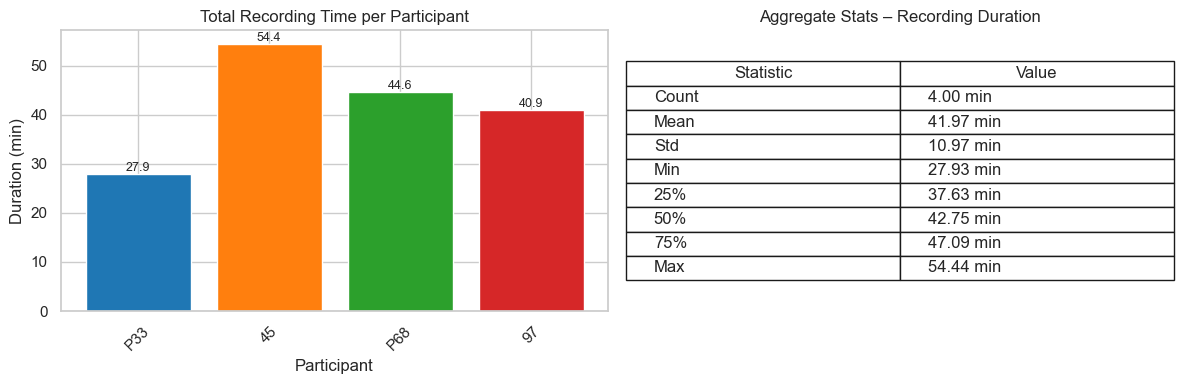

Total study time across all participants: 167.87 min (2.80 h)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Per-participant bar ──────────────────────────────────────────────────────
ax = axes[0]
ax.bar(overview_df["Participant"], overview_df["Duration (min)"], color=sns.color_palette("tab10"))
ax.set_title("Total Recording Time per Participant")
ax.set_ylabel("Duration (min)")
ax.set_xlabel("Participant")
ax.tick_params(axis="x", rotation=45)
for i, (_, row) in enumerate(overview_df.iterrows()):
    ax.text(i, row["Duration (min)"] + 0.05, f"{row['Duration (min)']:.1f}", ha="center", va="bottom", fontsize=9)

# ── Aggregate stats table ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.axis("off")
stats = overview_df["Duration (min)"].describe().round(2)
stats_rows = [[k.capitalize(), f"{v:.2f} min"] for k, v in stats.items()]
tbl = ax2.table(cellText=stats_rows, colLabels=["Statistic", "Value"],
                loc="center", cellLoc="left")
tbl.scale(1, 1.6)
ax2.set_title("Aggregate Stats – Recording Duration")

plt.tight_layout()
plt.show()

print(f"Total study time across all participants: "
      f"{overview_df['Duration (min)'].sum():.2f} min "
      f"({overview_df['Duration (min)'].sum()/60:.2f} h)")

## 3 · Time Spent per View

Time is extracted from `page_unload.duration_ms` (time between the matching
`page_load` and `page_unload` events). The **last view** of each session
(no `page_unload` fired before `session_end`) is computed from
`session_end.ts − last_page_load.ts`.

In [5]:
def compute_view_times(lg):
    """Returns {view: total_ms} for one participant log."""
    times = {v: 0 for v in VIEW_ORDER}
    events = lg["events"]
    session_end_ts = next(
        (e["ts"] for e in reversed(events) if e["type"] == "session_end"), None
    )

    # Accumulate durations from page_unload events (duration_ms = load→unload gap)
    for e in events:
        if e["type"] == "page_unload" and e["view"] in times:
            times[e["view"]] += e.get("duration_ms", 0)

    # Handle the last view (no page_unload before session_end / tab close)
    if session_end_ts:
        unload_ts_by_view = {}
        last_load_ts_by_view = {}
        for e in events:
            if e["type"] == "page_load":
                last_load_ts_by_view[e["view"]] = e["ts"]
            elif e["type"] == "page_unload":
                unload_ts_by_view[e["view"]] = e["ts"]

        for view, load_ts in last_load_ts_by_view.items():
            # If this page_load happened AFTER the last page_unload for that view → still open
            unload_ts = unload_ts_by_view.get(view, 0)
            if load_ts > unload_ts:
                times[view] += session_end_ts - load_ts

    return times


# ── Build per-participant view-time DataFrame (seconds) ─────────────────────
view_rows = []
for lg in logs:
    vt = compute_view_times(lg)
    row = {"Participant": lg["participant_id"]}
    for v in VIEW_ORDER:
        row[VIEW_LABELS[v]] = round(vt[v] / 1000, 1)
    view_rows.append(row)

view_df = pd.DataFrame(view_rows).set_index("Participant")
display(view_df.style.format("{:.1f} s"))

,Tabular Overview,Distribution Charts,Study Similarity,Study Timeline
Participant,,,,
P33,1519.1 s,26.0 s,102.1 s,12.9 s
45,2778.9 s,88.3 s,85.3 s,311.9 s
P68,1107.4 s,18.7 s,393.3 s,1131.2 s
97,2007.8 s,160.4 s,125.1 s,137.4 s


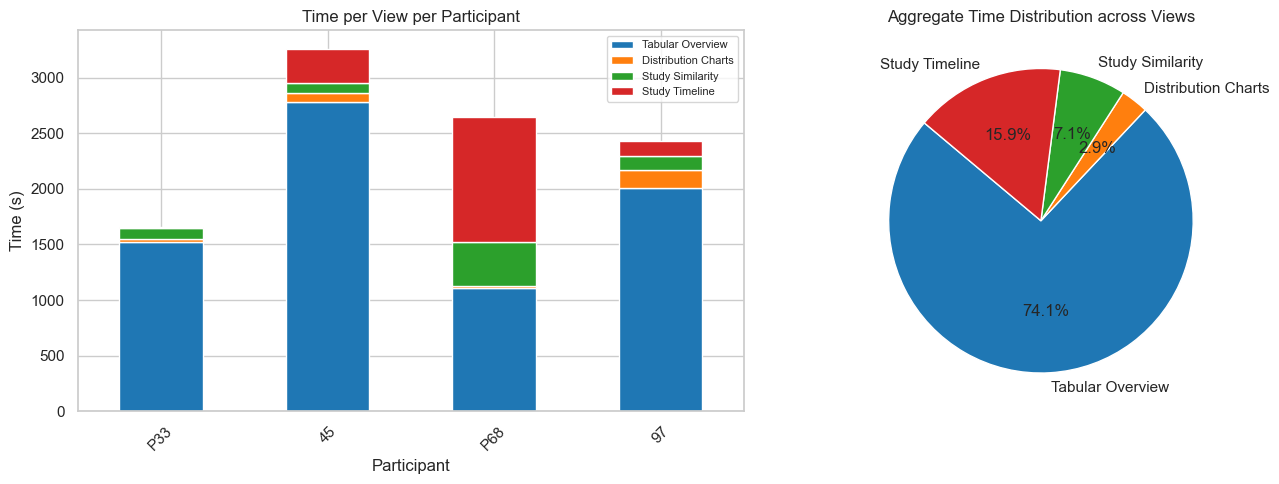

,Tabular Overview (%),Distribution Charts (%),Study Similarity (%),Study Timeline (%)
Participant,,,,
P33,91.5 %,1.6 %,6.2 %,0.8 %
45,85.1 %,2.7 %,2.6 %,9.6 %
P68,41.8 %,0.7 %,14.8 %,42.7 %
97,82.6 %,6.6 %,5.1 %,5.7 %


In [6]:
palette = sns.color_palette("tab10", len(VIEW_ORDER))
view_col_map = dict(zip([VIEW_LABELS[v] for v in VIEW_ORDER], palette))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Stacked bar: time per view per participant ───────────────────────────────
view_df.plot(kind="bar", stacked=True, ax=axes[0],
             color=[view_col_map[c] for c in view_df.columns])
axes[0].set_title("Time per View per Participant")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlabel("Participant")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="upper right", fontsize=8)

# ── Aggregate pie ────────────────────────────────────────────────────────────
agg_view = view_df.sum()
axes[1].pie(
    agg_view,
    labels=agg_view.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=[view_col_map[c] for c in agg_view.index],
)
axes[1].set_title("Aggregate Time Distribution across Views")

plt.tight_layout()
plt.show()

# ── Percentage table ─────────────────────────────────────────────────────────
pct_df = view_df.div(view_df.sum(axis=1), axis=0).mul(100).round(1)
pct_df.columns = [f"{c} (%)" for c in pct_df.columns]
display(pct_df.style.format("{:.1f} %"))

## 4 · Feature / Element Usage

Maps every logged event to a meaningful **feature category** to answer:

> *"Which parts, views, filters, or information did you spend the most time with / use most often?"*

Infrastructure events (`session_start/end`, `page_load/unload`, `window_hidden/visible`)
are excluded from counts.  Residual noise (drag-release clicks landing on unclassified
sidebar divs) is labeled **Sidebar: drag-release noise** so it can be identified and
excluded from totals if desired.

In [7]:
NOISE_LABEL = "⚠ drag-release noise"

def classify_event(e):
    """Return a human-readable feature category, or None for infrastructure events."""
    t    = e["type"]
    view = e.get("view", "")

    # ── Infrastructure ──────────────────────────────────────────────────────
    if t in ("session_start", "session_end",
             "page_load", "page_unload",
             "window_hidden", "window_visible"):
        return None

    # ── Filters ─────────────────────────────────────────────────────────────
    if t == "filter_checkbox_toggled":    return "Filter: Checkbox"
    if t == "range_filter_moved":         return "Filter: Range Slider"
    if t == "token_filter_added":         return "Filter: Token Add"
    if t == "token_filter_removed":       return "Filter: Token Remove"
    if t == "exclusive_filter_toggled":   return "Filter: Exclusive Toggle"
    if t == "sidebar_interaction":
        st = e.get("subtype", "general")
        mapping = {
            "global_select_all":       "Filter: Global Select All",
            "global_deselect_all":     "Filter: Global Deselect All",
            "panel_select_all":        "Filter: Panel Select All",
            "panel_deselect_all":      "Filter: Panel Deselect All",
            "category_select_all":     "Filter: Category Select All",
            "category_deselect_all":   "Filter: Category Deselect All",
            "token_clear_all":         "Filter: Token Clear All",
            "exclusive_filter_toggled":"Filter: Exclusive Toggle",
            "sidebar_closed":          "Sidebar: Close Sidebar",
            "panel_expand_collapse":   "Sidebar: Panel Expand/Collapse",
        }
        return mapping.get(st)   # None for 'general' -> not counted

    # ── View controls ────────────────────────────────────────────────────────
    if t == "dropdown_changed":   return "View Controls: Dropdown"
    if t == "radio_changed":      return "View Controls: Radio Button"

    # -- Header buttons (EarXplore Paper, Add Study, etc.) ------
    if t == "header_button_clicked": return "Header: Button Clicked"

    # ── Table / columns ──────────────────────────────────────────────────────
    if t == "column_visibility_toggled": return "Column Visibility"
    if t == "column_sort_clicked":       return "Table: Column Sort"
    if t == "csv_download_clicked":      return "Export: Download CSV"

    # ── Study detail & links ─────────────────────────────────────────────────
    if t == "study_detail_opened":   return "Study Detail: Open"
    if t == "study_detail_closed":   return None   # paired with open; don't double-count
    if t == "paper_link_opened":     return "Study Detail: Open Paper URL"
    if t == "find_similar_clicked":  return "Study Detail: Find Similar"

    # ── Modals ───────────────────────────────────────────────────────────────
    if t == "modal_opened":
        mid = e.get("id", "")
        if mid == "connectionsModal":  return "Similarity: Open Connections Modal"
        if mid == "timelineConnectionsModal": return "Timeline: Open Connections Modal"
        if mid == "table-modal":       return "Bar Chart: Open Table Modal"
        return f"Modal: Open ({mid})"
    if t in ("modal_closed", "modal_button_clicked"):
        return None   # closing / button-inside-modal covered by higher-level events

    # ── Chatbot ──────────────────────────────────────────────────────────────
    if t == "chatbot_opened":        return "Chatbot: Open"
    if t == "chatbot_closed":        return None
    if t == "chatbot_message_sent":  return "Chatbot: Send Message"
    if t == "chatbot_reset":         return "Chatbot: Reset"

    # ── Navigation ───────────────────────────────────────────────────────────
    if t == "navigate_to_view":      return "Navigation: View Switch"

    # ── General / unclassified clicks ────────────────────────────────────────
    if t == "general_click":
        tag   = e.get("el", {}).get("tag", "").lower()
        el_id = e.get("el", {}).get("id", "")
        if tag == "canvas" or el_id.startswith("chart-"):
            return "Bar Chart: Click on Bar"
        if tag in ("path", "circle", "rect", "g", "svg"):
            if view == "similarityView": return "Similarity: Click on Graph Node"
            if view == "timeView":        return "Timeline: Click on Node/Link"
            return "Graph: Click on Node"
        if tag == "td":
            return "Table: Row Click"
        if el_id == "chatbot-overlay":   # backdrop click in older logs
            return None
        return NOISE_LABEL

    return None


# Quick sanity check
sample_types = {e["type"] for lg in logs for e in lg["events"]}
classified = {t: classify_event({"type": t}) for t in sample_types}
print("Event type → feature category mapping:")
for t, c in sorted(classified.items()):
    print(f"  {t:<35} → {c}")

Event type → feature category mapping:
  chatbot_closed                      → None
  chatbot_message_sent                → Chatbot: Send Message
  chatbot_opened                      → Chatbot: Open
  column_sort_clicked                 → Table: Column Sort
  column_visibility_toggled           → Column Visibility
  dropdown_changed                    → View Controls: Dropdown
  exclusive_filter_toggled            → Filter: Exclusive Toggle
  filter_checkbox_toggled             → Filter: Checkbox
  find_similar_clicked                → Study Detail: Find Similar
  general_click                       → ⚠ drag-release noise
  header_button_clicked               → Header: Button Clicked
  modal_button_clicked                → None
  modal_closed                        → None
  modal_opened                        → Modal: Open ()
  navigate_to_view                    → Navigation: View Switch
  page_load                           → None
  page_unload                         → None
  paper

In [8]:
# ── Feature counts per participant ──────────────────────────────────────────
feature_rows = []
for lg in logs:
    counts: dict[str, int] = {}
    for e in lg["events"]:
        f = classify_event(e)
        if f:
            counts[f] = counts.get(f, 0) + 1
    feature_rows.append({"Participant": lg["participant_id"], **counts})

feat_df = (
    pd.DataFrame(feature_rows)
    .fillna(0)
    .set_index("Participant")
    .astype(int)
)

# Sort columns by aggregate usage (descending)
col_order = feat_df.sum().sort_values(ascending=False).index
feat_df = feat_df[col_order]

display(feat_df.T.style.background_gradient(cmap="YlOrRd", axis=1))

Participant,P33,45,P68,97
Filter: Checkbox,11,72,7,18
⚠ drag-release noise,17,27,30,14
Study Detail: Open,14,10,40,10
Column Visibility,4,18,1,42
Table: Row Click,6,43,7,1
Navigation: View Switch,10,8,14,8
View Controls: Radio Button,4,4,10,13
Timeline: Click on Node/Link,0,1,20,1
Study Detail: Open Paper URL,0,5,7,7
Timeline: Open Connections Modal,0,0,18,1


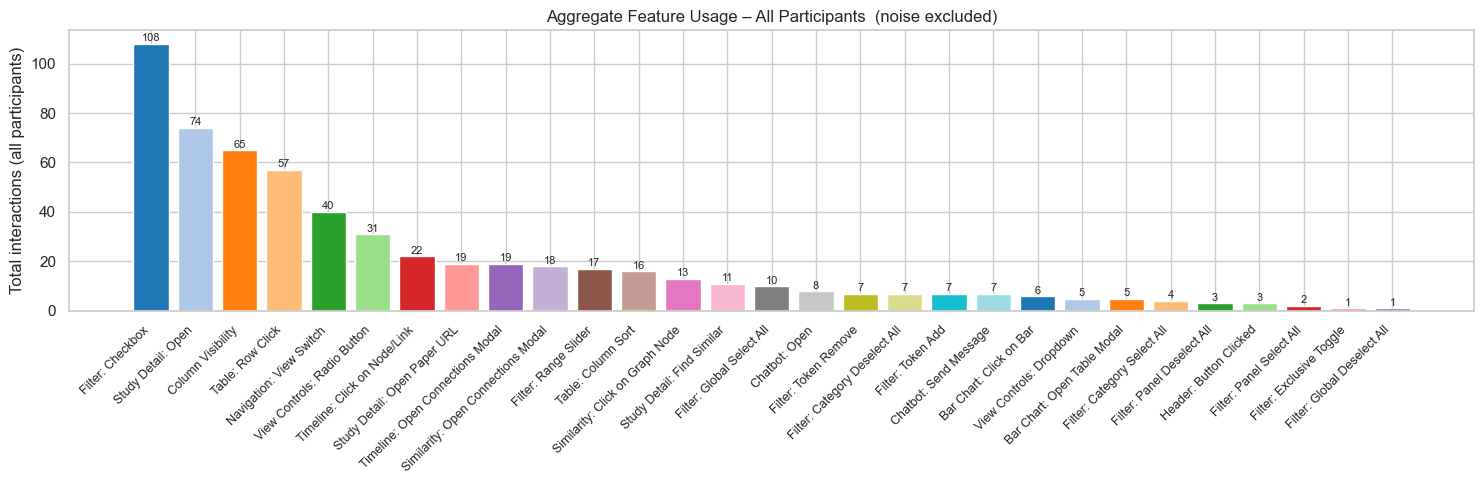

In [9]:
# ── Aggregate feature usage – bar chart ─────────────────────────────────────
# Exclude noise label from the main chart
agg_feat = feat_df.drop(columns=[NOISE_LABEL], errors="ignore").sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 5))
colors = sns.color_palette("tab20", len(agg_feat))
bars = ax.bar(range(len(agg_feat)), agg_feat.values, color=colors)
ax.set_xticks(range(len(agg_feat)))
ax.set_xticklabels(agg_feat.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Total interactions (all participants)")
ax.set_title("Aggregate Feature Usage – All Participants  (noise excluded)")

for bar, val in zip(bars, agg_feat.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

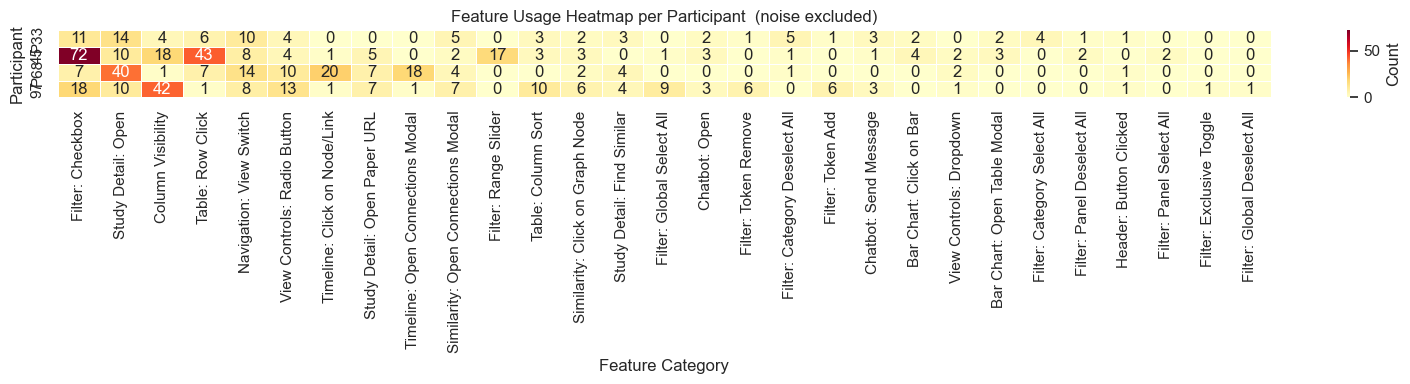

In [10]:
# ── Per-participant heatmap (only meaningful with ≥2 participants) ───────────
clean_feat_df = feat_df.drop(columns=[NOISE_LABEL], errors="ignore")

if len(logs) >= 2:
    fig, ax = plt.subplots(figsize=(16, max(4, len(logs) * 0.9)))
    sns.heatmap(clean_feat_df, annot=True, fmt="d", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Count"})
    ax.set_title("Feature Usage Heatmap per Participant  (noise excluded)")
    ax.set_xlabel("Feature Category")
    ax.set_ylabel("Participant")
    plt.tight_layout()
    plt.show()
else:
    print("Only one participant in the dataset – heatmap omitted.")

## 5 · Per-Participant Summary

Compact text report per participant: view time breakdown + ranked feature list.
This is the data equivalent of the interview question:
*"Which parts, views, filters, or information did you spend the most time with?"*

In [11]:
for lg in logs:
    pid = lg["participant_id"]
    vt  = compute_view_times(lg)
    total_ms = sum(vt.values())

    # Feature counts (noise excluded)
    counts: dict[str, int] = {}
    for e in lg["events"]:
        f = classify_event(e)
        if f and f != NOISE_LABEL:
            counts[f] = counts.get(f, 0) + 1

    sorted_feats = sorted(counts.items(), key=lambda x: x[1], reverse=True)

    print("=" * 65)
    print(f"  Participant : {pid}")
    start = datetime.fromisoformat(lg["recorded_from"].replace("Z", "+00:00"))
    end   = datetime.fromisoformat(lg["recorded_to"].replace("Z", "+00:00"))
    dur   = (end - start).total_seconds()
    print(f"  Duration    : {dur:.0f} s  ({dur/60:.1f} min)")
    print(f"  Total events: {lg['total_events']}")
    print("=" * 65)

    print("\n  Time per view:")
    for v in VIEW_ORDER:
        ms  = vt[v]
        pct = (ms / total_ms * 100) if total_ms > 0 else 0
        bar = "█" * int(pct / 5)
        print(f"  {VIEW_LABELS[v]:<28} {ms/1000:6.1f}s  {pct:5.1f}%  {bar}")

    print(f"\n  Top interactions ({len(sorted_feats)} feature types used):")
    for feat, cnt in sorted_feats[:15]:
        print(f"    {cnt:3d}×  {feat}")
    print()

  Participant : P33
  Duration    : 1676 s  (27.9 min)
  Total events: 186

  Time per view:
  Tabular Overview             1519.1s   91.5%  ██████████████████
  Distribution Charts            26.0s    1.6%  
  Study Similarity              102.1s    6.1%  █
  Study Timeline                 12.9s    0.8%  

  Top interactions (20 feature types used):
     14×  Study Detail: Open
     11×  Filter: Checkbox
     10×  Navigation: View Switch
      6×  Table: Row Click
      5×  Filter: Category Deselect All
      5×  Similarity: Open Connections Modal
      4×  Column Visibility
      4×  Filter: Category Select All
      4×  View Controls: Radio Button
      3×  Table: Column Sort
      3×  Chatbot: Send Message
      3×  Study Detail: Find Similar
      2×  Bar Chart: Click on Bar
      2×  Bar Chart: Open Table Modal
      2×  Chatbot: Open

  Participant : 45
  Duration    : 3266 s  (54.4 min)
  Total events: 326

  Time per view:
  Tabular Overview             2778.9s   85.1%  ██████

## 6 · Detailed Filter Analysis

Which **specific filter columns** did participants interact with most?

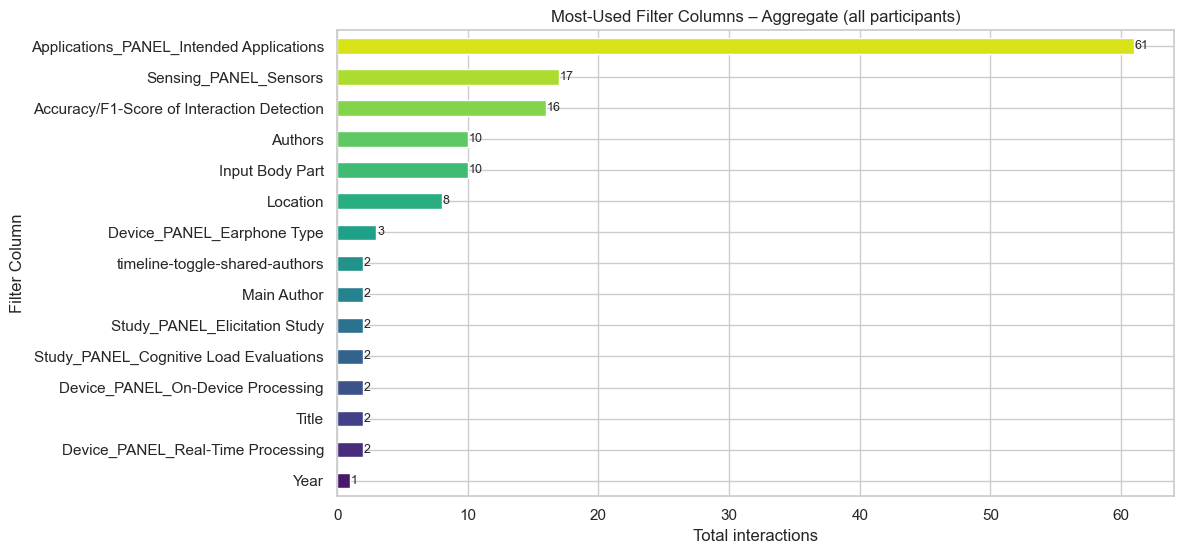

Filter Column,Accuracy/F1-Score of Interaction Detection,Applications_PANEL_Intended Applications,Authors,Device_PANEL_Earphone Type,Device_PANEL_On-Device Processing,Device_PANEL_Real-Time Processing,Input Body Part,Location,Main Author,Sensing_PANEL_Sensors,Study_PANEL_Cognitive Load Evaluations,Study_PANEL_Elicitation Study,Title,Year,timeline-toggle-shared-authors
Participant,,,,,,,,,,,,,,,
45,16,58,0,0,0,0,4,6,0,0,2,2,0,1,0
97,0,0,10,3,2,2,0,0,2,12,0,0,0,0,0
P33,0,3,0,0,0,0,6,2,0,0,0,0,2,0,0
P68,0,0,0,0,0,0,0,0,0,5,0,0,0,0,2


In [12]:
FILTER_EVENT_TYPES = {
    "filter_checkbox_toggled",
    "range_filter_moved",
    "token_filter_added",
    "token_filter_removed",
    "exclusive_filter_toggled",
}

filter_col_records = []
for lg in logs:
    pid = lg["participant_id"]
    for e in lg["events"]:
        col = e.get("col")
        if col and e["type"] in FILTER_EVENT_TYPES:
            filter_col_records.append({
                "Participant":    pid,
                "Filter Column":  col,
                "Event Type":     e["type"],
                "View":           VIEW_LABELS.get(e.get("view", ""), e.get("view", "")),
            })

if filter_col_records:
    fc_df = pd.DataFrame(filter_col_records)

    # Aggregate: total interactions per filter column
    agg_fc = (
        fc_df.groupby("Filter Column")
        .size()
        .sort_values(ascending=True)
        .rename("Total Interactions")
    )

    fig, ax = plt.subplots(figsize=(12, max(4, len(agg_fc) * 0.38)))
    agg_fc.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(agg_fc)))
    ax.set_title("Most-Used Filter Columns – Aggregate (all participants)")
    ax.set_xlabel("Total interactions")
    for i, v in enumerate(agg_fc.values):
        ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    # Per-participant breakdown
    per_p = (
        fc_df.groupby(["Participant", "Filter Column"])
        .size()
        .unstack(fill_value=0)
    )
    display(per_p.style.background_gradient(cmap="YlOrRd", axis=None))
else:
    print("No filter-column data found in the loaded logs.")

## 7 · Navigation Patterns

How often did participants visit each view, and what were the most common view-to-view transitions?

View,Distribution Charts,Study Similarity,Tabular Overview,Study Timeline
Participant,,,,
45,3,2,2,2
97,1,3,6,2
P33,2,5,7,2
P68,3,5,5,5



Aggregate view visit counts:
  Tabular Overview              20  ████████████████████
  Study Similarity              15  ███████████████
  Study Timeline                11  ███████████
  Distribution Charts            9  █████████



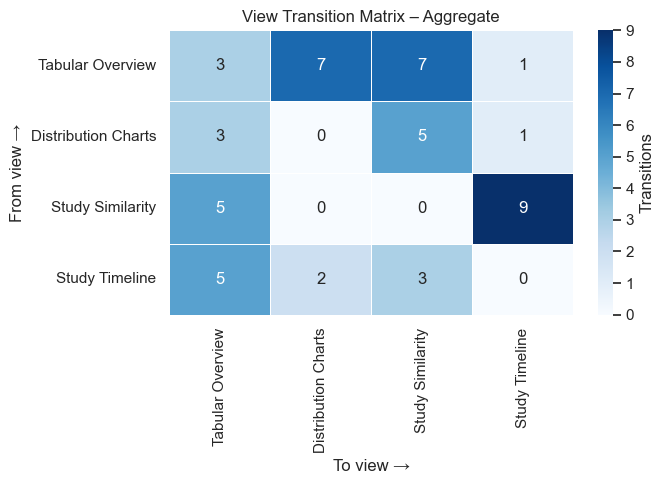

In [13]:
# ── View visit counts ────────────────────────────────────────────────────────
nav_records = []
for lg in logs:
    pid = lg["participant_id"]
    for e in lg["events"]:
        if e["type"] == "page_load":
            nav_records.append({"Participant": pid, "View": e["view"]})

nav_df = pd.DataFrame(nav_records)
visit_counts = (
    nav_df.groupby(["Participant", "View"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=VIEW_LABELS)
)
display(visit_counts.style.background_gradient(cmap="Blues", axis=None))

# ── Aggregate visit share ────────────────────────────────────────────────────
agg_visits = visit_counts.sum().sort_values(ascending=False)
print("\nAggregate view visit counts:")
for v, cnt in agg_visits.items():
    print(f"  {v:<28} {cnt:3d}  {'█' * int(cnt)}")

# ── Transition matrix (aggregate) ───────────────────────────────────────────
print()
trans_matrix = pd.DataFrame(0,
    index=[VIEW_LABELS[v] for v in VIEW_ORDER],
    columns=[VIEW_LABELS[v] for v in VIEW_ORDER],
)
for lg in logs:
    views_seq = [
        e["view"] for e in lg["events"]
        if e["type"] == "page_load" and e["view"] in VIEW_ORDER
    ]
    for from_v, to_v in zip(views_seq[:-1], views_seq[1:]):
        trans_matrix.loc[VIEW_LABELS[from_v], VIEW_LABELS[to_v]] += 1

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(trans_matrix, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Transitions"})
ax.set_title("View Transition Matrix – Aggregate")
ax.set_xlabel("To view →")
ax.set_ylabel("From view →")
plt.tight_layout()
plt.show()